Monte Carlo Results:
Mean demand after 10 years: 69.87
Std dev: 5.91
99th percentile: 84.05


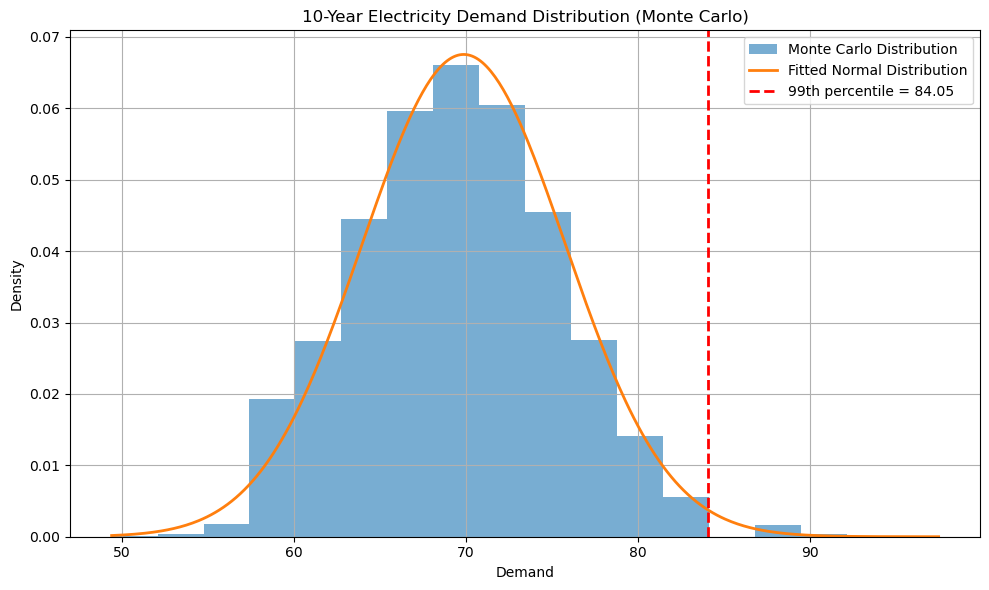

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------
# PARAMETERS
# -----------------------------
base_demand = 39
years = 10
N = 200_000  # Monte Carlo samples

# Discrete growth distribution
multipliers = np.array([1.02, 1.06, 1.10])
probs = np.array([0.25, 0.50, 0.25])

# -----------------------------
# MONTE CARLO SIMULATION
# -----------------------------
# Draw annual multipliers for each sample
draws = np.random.choice(multipliers, size=(N, years), p=probs)

# Compute final demand after 10 years
final_demand = base_demand * draws.prod(axis=1)

# -----------------------------
# STATISTICS
# -----------------------------
mean_val = np.mean(final_demand)
std_val = np.std(final_demand, ddof=1)
p99 = np.percentile(final_demand, 99)

print("Monte Carlo Results:")
print(f"Mean demand after 10 years: {mean_val:.2f}")
print(f"Std dev: {std_val:.2f}")
print(f"99th percentile: {p99:.2f}")

# -----------------------------
# PLOT HISTOGRAM + NORMAL FIT
# -----------------------------
plt.figure(figsize=(10, 6))

# Histogram
count, bins, _ = plt.hist(final_demand, bins=18, density=True, alpha=0.6,
                          label='Monte Carlo Distribution')

# Normal PDF fit
x = np.linspace(min(final_demand), max(final_demand), 400)
pdf = norm.pdf(x, loc=mean_val, scale=std_val)
plt.plot(x, pdf, linewidth=2, label='Fitted Normal Distribution')

# 99th percentile line
plt.axvline(p99, color='red', linestyle='--', linewidth=2,
            label=f'99th percentile = {p99:.2f}')

plt.title("10-Year Electricity Demand Distribution (Monte Carlo)")
plt.xlabel("Demand")
plt.ylabel("Density")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

